In [1]:
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import protfasta
from parrot import py_predictor


Error importing GPy.
 If trying to run parrot-optimize, make sure to use `pip install idptools-parrot[optimize]`


In [3]:
megan_TF_seqs = protfasta.read_fasta("../data/megan_TFs.fasta")
megan_TF_seqs = pd.DataFrame({'id' : megan_TF_seqs.keys(), 'sequence' : megan_TF_seqs.values()})
megan_TF_seqs

,id,sequence
0,NP_571323.1 early growth response protein 1 Eg...,MAAAKTEMLLPALQISDPLSFPHSPTDNYPKLEEMIMLNSAGTPFL...
1,NP_955809.2 PR domain zinc finger protein 1a P...,MCGWDQSVLAPYQNSAMLTTEAAPYTADNEELKMDVEDVDMTKWTE...
2,NP_571719.1 transcription factor SOX-9b [Danio...,MNLLQRGLKMSVSGAPSPSLSEDSAGSPCASAGSGSDSETPRAEPP...
3,NP_571718.1 transcription factor SOX-9a [Danio...,MNLLDPYLKMTDEQEKCLSDAPSPSMSEDSAGSPCPSASGSDTENT...
4,NP_571950.1 transcription factor SOX-10 [Danio...,MSAEEHSMSEVEMSPGVSDDGHSMSPGHSSGAPGGADSPLPGQQSQ...
5,NP_001017558.1 protein C-ets-1 [Danio rerio],MTAAVDIKPLTIIKSEKVDDLECADVPLLTPGSKEMMSQALLATFS...
6,NP_001020636.2 transcription factor SOX-8b [Da...,MSEEREKCSSPTGSCSSECPDECDSDPSCSPAGPAALRMGQQAEDE...
7,AAX73357.1 Sox8 [Danio rerio],MSEEREKCSSPTGSCSSECPDECDSDPSCSPAGPAALRMGQQAEDE...
8,NP_571423.1 Friend leukemia integration 1 tran...,MDGTIKEALSVVSEDQSLFEPPYAAAAPLPKTDMTASGTQDYGQTH...
9,XP_005159335.1 Friend leukemia integration 1 t...,MTMFQTVPDTSSYVKEALSVVSEDQSLFEPPYAAAAPLPKTDMTAS...


In [4]:
megan_TF_preds = pd.read_csv("../data/megan_TF_preds.csv", index_col = 0)
megan_TF_preds = pd.merge(megan_TF_preds, megan_TF_seqs, on = "sequence", how = "left")
megan_TF_preds

,sequence,paddle_centers,paddle_preds,adpred_preds,adhunter_centers,adhunter_preds,tada_centers,tada_preds,id
0,MAAAKTEMLLPALQISDPLSFPHSPTDNYPKLEEMIMLNSAGTPFL...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[2.352715015411377, 2.5738685131073, 2.7197709...","[0.003882537828758359, 0.0022542234510183334, ...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[75518.609375, 62451.9765625, 55790.921875, 46...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.3959558308124542, 0.40744549036026, 0.39761...",NP_571323.1 early growth response protein 1 Eg...
1,MCGWDQSVLAPYQNSAMLTTEAAPYTADNEELKMDVEDVDMTKWTE...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[6.341304779052734, 5.92863130569458, 5.857869...","[0.010110163129866123, 0.007923339493572712, 0...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[31424.05078125, 31840.3125, 31955.25390625, 2...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.3985865116119385, 0.4041998088359833, 0.413...",NP_955809.2 PR domain zinc finger protein 1a P...
2,MNLLQRGLKMSVSGAPSPSLSEDSAGSPCASAGSGSDSETPRAEPP...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.029335450381040573, 0.03371461108326912, 0....","[0.0007308918866328895, 0.0005036980146542192,...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[20433.26171875, 19678.76953125, 21519.4921875...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.1664242148399353, 0.16366331279277802, 0.14...",NP_571719.1 transcription factor SOX-9b [Danio...
3,MNLLDPYLKMTDEQEKCLSDAPSPSMSEDSAGSPCPSASGSDTENT...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.45552191138267517, 0.4340111315250397, 0.41...","[0.020246338099241257, 0.009077892638742924, 0...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[28010.8515625, 23717.60546875, 25608.7421875,...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.2231655865907669, 0.21778230369091034, 0.20...",NP_571718.1 transcription factor SOX-9a [Danio...
4,MSAEEHSMSEVEMSPGVSDDGHSMSPGHSSGAPGGADSPLPGQQSQ...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.6168835759162903, 0.5924018025398254, 0.580...","[0.0008535209344699979, 0.0010266114259138703,...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[18167.82421875, 22306.71484375, 22925.1835937...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.17705407738685608, 0.1897444725036621, 0.17...",NP_571950.1 transcription factor SOX-10 [Danio...
5,MTAAVDIKPLTIIKSEKVDDLECADVPLLTPGSKEMMSQALLATFS...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.11386103928089142, 0.10231888294219971, 0.0...","[0.0012131157563999295, 0.0012521286262199283,...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[62217.8125, 60584.69921875, 60381.6171875, 60...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.24308475852012634, 0.2460855096578598, 0.25...",NP_001017558.1 protein C-ets-1 [Danio rerio]
6,MSEEREKCSSPTGSCSSECPDECDSDPSCSPAGPAALRMGQQAEDE...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.8125362396240234, 0.8636775016784668, 0.904...","[0.00015259945939760655, 0.0001532882452011108...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[33552.7578125, 28029.45703125, 25171.19140625...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.18771342933177948, 0.18620386719703674, 0.1...",NP_001020636.2 transcription factor SOX-8b [Da...
7,MSEEREKCSSPTGSCSSECPDECDSDPSCSPAGPAALRMGQQAEDE...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.8100597262382507, 0.8599701523780823, 0.899...","[0.00015259945939760655, 0.0001532882452011108...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[33552.7578125, 28029.45703125, 25171.19140625...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.18771342933177948, 0.18620386719703674, 0.1...",AAX73357.1 Sox8 [Danio rerio]
8,MDGTIKEALSVVSEDQSLFEPPYAAAAPLPKTDMTASGTQDYGQTH...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.7203852534294128, 0.797517716884613, 0.9758...","[0.001963124144822359, 0.00198

In [5]:
for col in megan_TF_preds.columns[1:-1]:
    megan_TF_preds[col] = megan_TF_preds[col].str[1:-1].str.replace(" ", "").str.split(",")
    
    megan_TF_preds[col] = [[float(_) for _ in str_list] for str_list in megan_TF_preds[col]]
megan_TF_preds

,sequence,paddle_centers,paddle_preds,adpred_preds,adhunter_centers,adhunter_preds,tada_centers,tada_preds,id
0,MAAAKTEMLLPALQISDPLSFPHSPTDNYPKLEEMIMLNSAGTPFL...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[2.352715015411377, 2.5738685131073, 2.7197709...","[0.003882537828758359, 0.0022542234510183334, ...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[75518.609375, 62451.9765625, 55790.921875, 46...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.3959558308124542, 0.40744549036026, 0.39761...",NP_571323.1 early growth response protein 1 Eg...
1,MCGWDQSVLAPYQNSAMLTTEAAPYTADNEELKMDVEDVDMTKWTE...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[6.341304779052734, 5.92863130569458, 5.857869...","[0.010110163129866123, 0.007923339493572712, 0...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[31424.05078125, 31840.3125, 31955.25390625, 2...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.3985865116119385, 0.4041998088359833, 0.413...",NP_955809.2 PR domain zinc finger protein 1a P...
2,MNLLQRGLKMSVSGAPSPSLSEDSAGSPCASAGSGSDSETPRAEPP...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.029335450381040573, 0.03371461108326912, 0....","[0.0007308918866328895, 0.0005036980146542192,...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[20433.26171875, 19678.76953125, 21519.4921875...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.1664242148399353, 0.16366331279277802, 0.14...",NP_571719.1 transcription factor SOX-9b [Danio...
3,MNLLDPYLKMTDEQEKCLSDAPSPSMSEDSAGSPCPSASGSDTENT...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.45552191138267517, 0.4340111315250397, 0.41...","[0.020246338099241257, 0.009077892638742924, 0...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[28010.8515625, 23717.60546875, 25608.7421875,...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.2231655865907669, 0.21778230369091034, 0.20...",NP_571718.1 transcription factor SOX-9a [Danio...
4,MSAEEHSMSEVEMSPGVSDDGHSMSPGHSSGAPGGADSPLPGQQSQ...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.6168835759162903, 0.5924018025398254, 0.580...","[0.0008535209344699979, 0.0010266114259138703,...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[18167.82421875, 22306.71484375, 22925.1835937...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.17705407738685608, 0.1897444725036621, 0.17...",NP_571950.1 transcription factor SOX-10 [Danio...
5,MTAAVDIKPLTIIKSEKVDDLECADVPLLTPGSKEMMSQALLATFS...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.11386103928089142, 0.10231888294219971, 0.0...","[0.0012131157563999295, 0.0012521286262199283,...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[62217.8125, 60584.69921875, 60381.6171875, 60...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.24308475852012634, 0.2460855096578598, 0.25...",NP_001017558.1 protein C-ets-1 [Danio rerio]
6,MSEEREKCSSPTGSCSSECPDECDSDPSCSPAGPAALRMGQQAEDE...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.8125362396240234, 0.8636775016784668, 0.904...","[0.00015259945939760655, 0.0001532882452011108...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[33552.7578125, 28029.45703125, 25171.19140625...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.18771342933177948, 0.18620386719703674, 0.1...",NP_001020636.2 transcription factor SOX-8b [Da...
7,MSEEREKCSSPTGSCSSECPDECDSDPSCSPAGPAALRMGQQAEDE...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.8100597262382507, 0.8599701523780823, 0.899...","[0.00015259945939760655, 0.0001532882452011108...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[33552.7578125, 28029.45703125, 25171.19140625...","[20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27....","[0.18771342933177948, 0.18620386719703674, 0.1...",AAX73357.1 Sox8 [Danio rerio]
8,MDGTIKEALSVVSEDQSLFEPPYAAAAPLPKTDMTASGTQDYGQTH...,"[27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34....","[0.7203852534294128, 0.797517716884613, 0.9758...","[0.001963124144822359, 0.00198

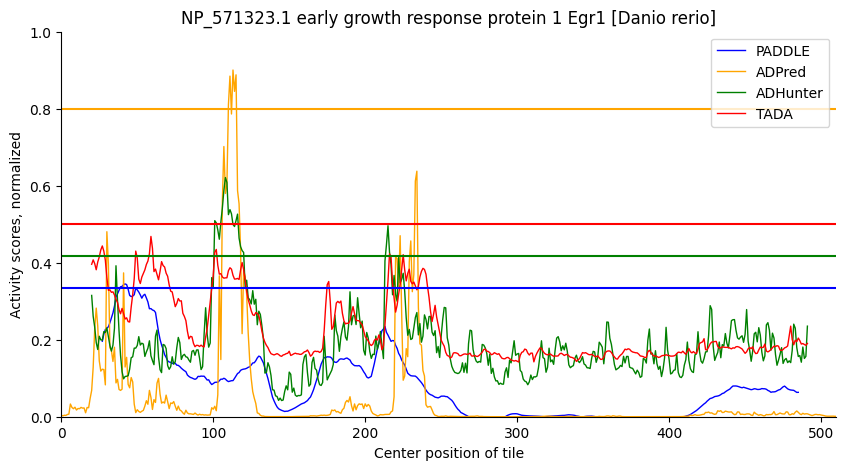

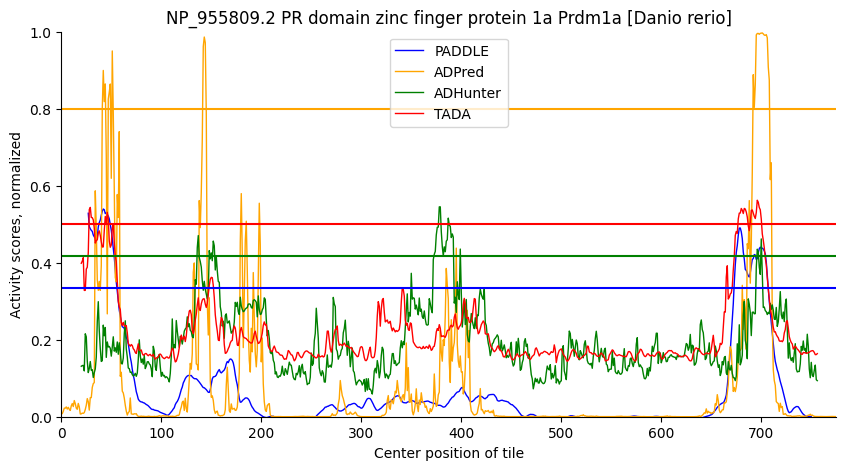

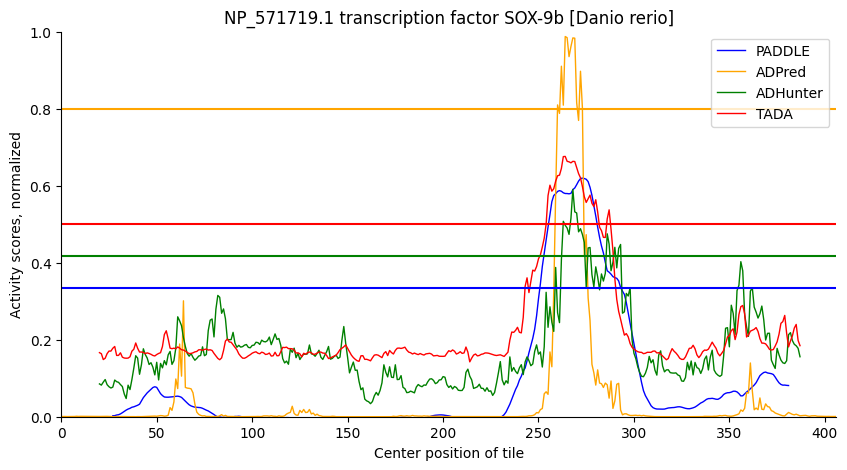

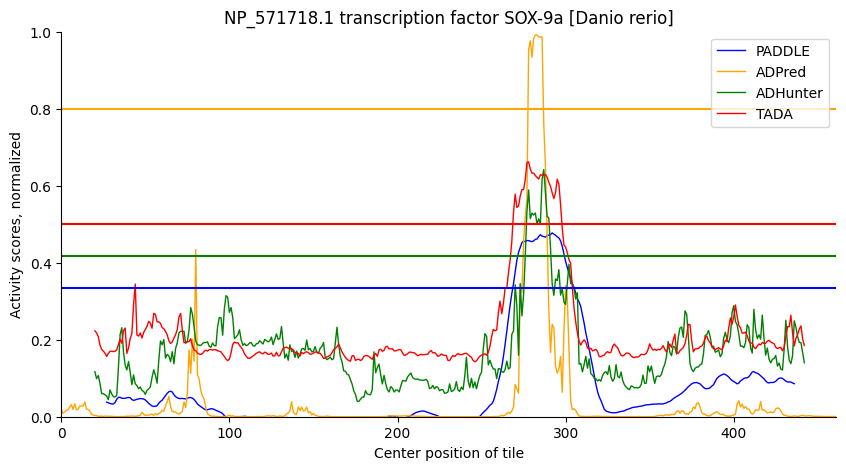

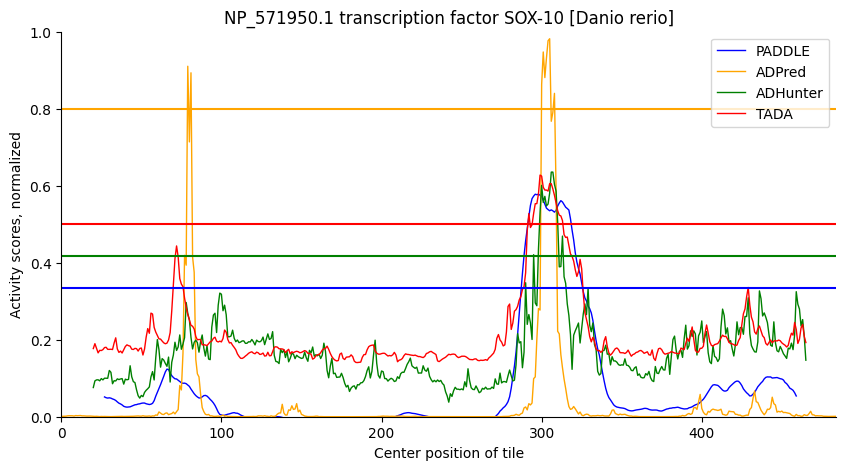

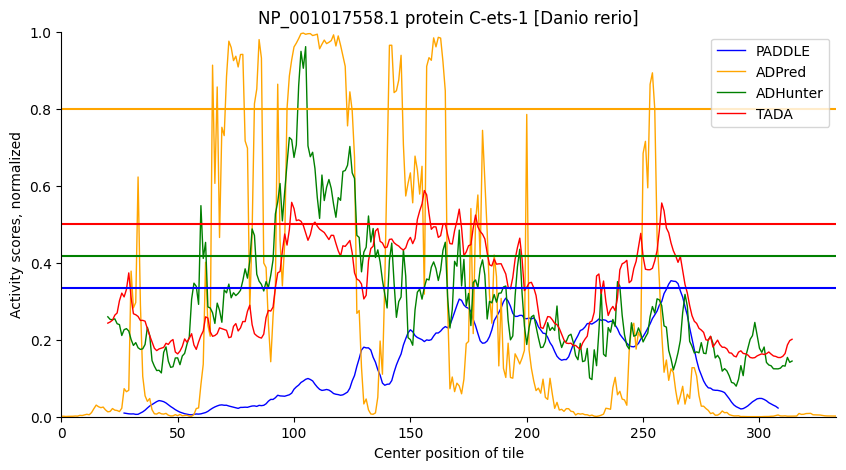

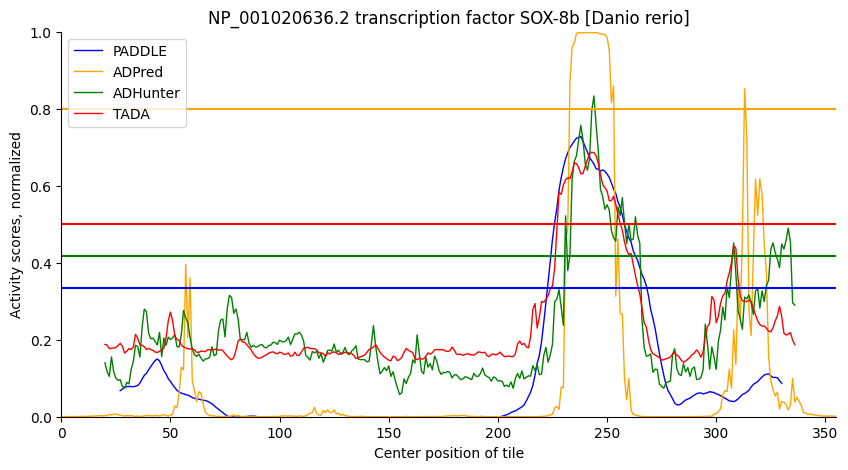

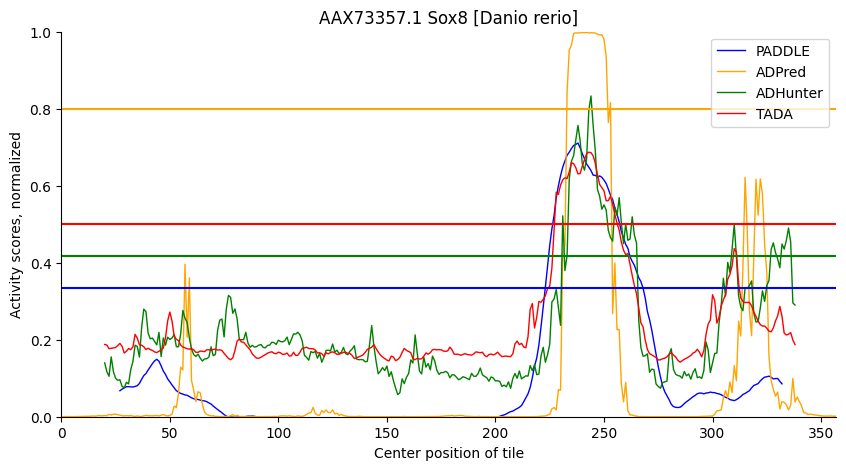

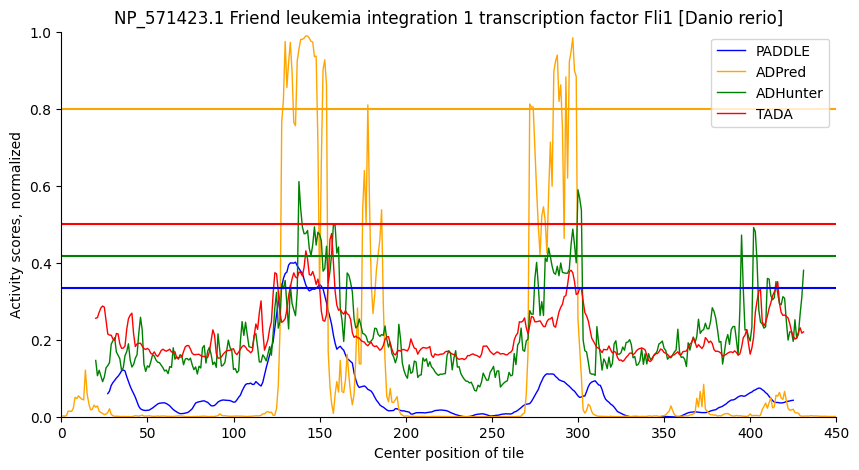

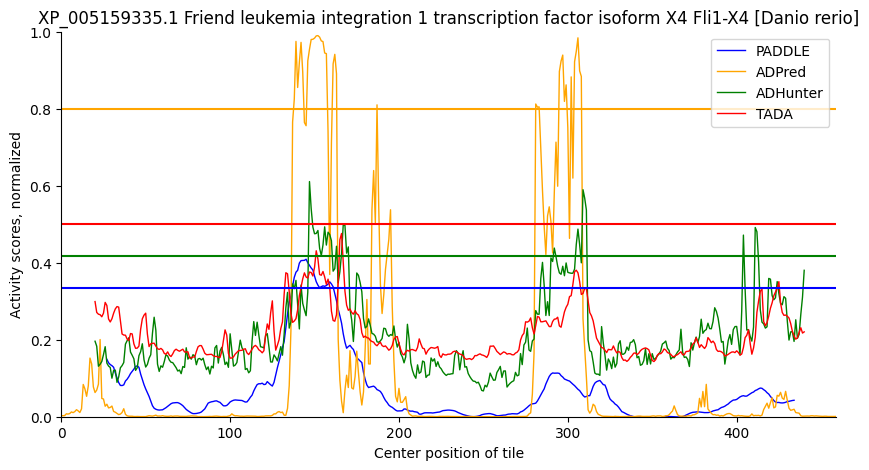

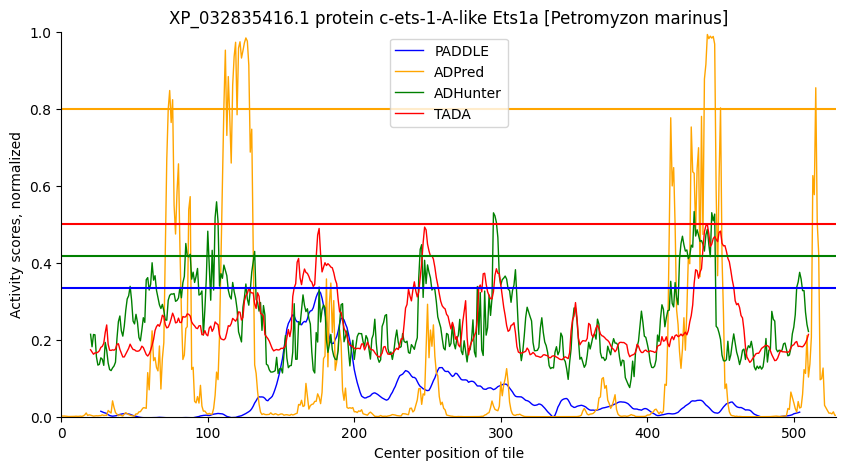

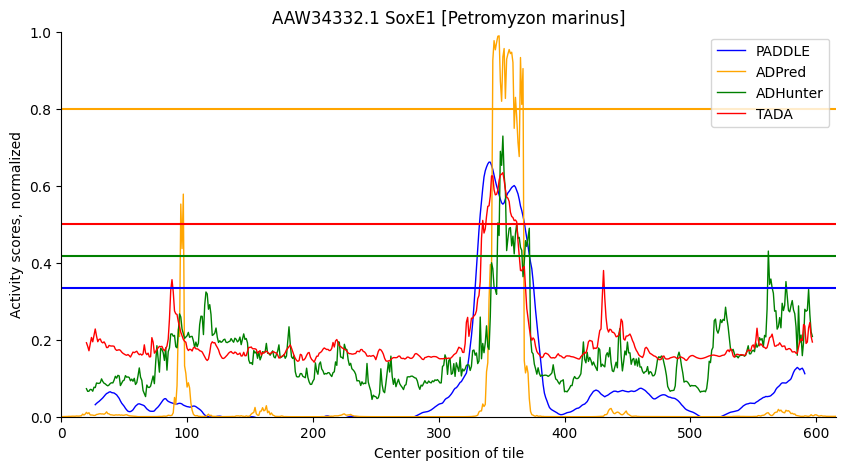

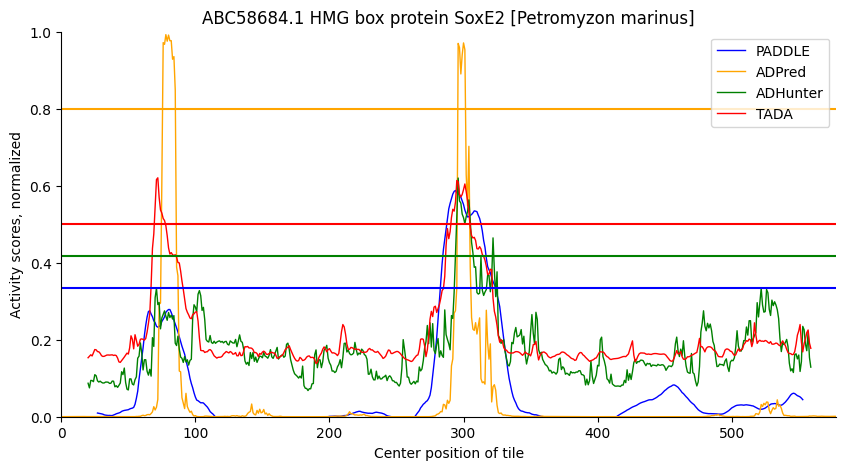

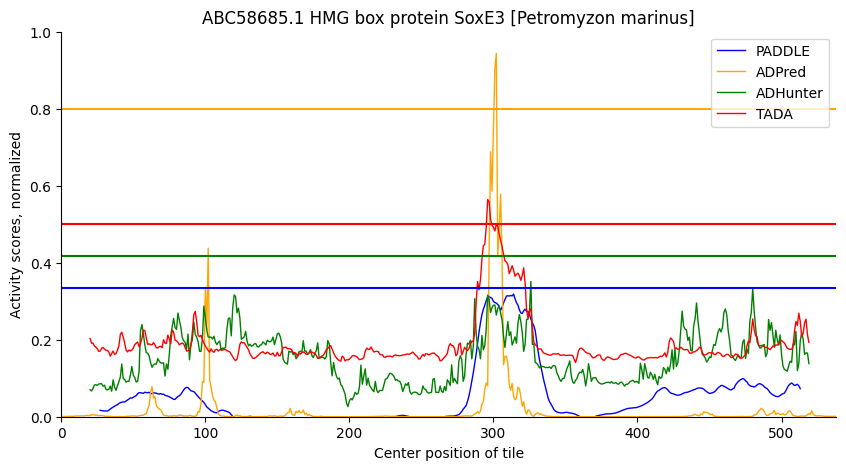

In [6]:
def normalize_paddle(arr):
    arr = np.array(arr)
    return arr/12

def normalize_adhunter(arr):
    arr = np.array(arr)
    return arr/239716
    
#pdf = matplotlib.backends.backend_pdf.PdfPages("../output/megan_TF_traces.pdf")

for i in megan_TF_preds.index:
    sequence = megan_TF_preds["sequence"].iloc[i]
    paddle_centers, paddle_preds = megan_TF_preds["paddle_centers"].iloc[i], megan_TF_preds["paddle_preds"].iloc[i]
    adpred_preds = megan_TF_preds["adpred_preds"].iloc[i]
    adhunter_centers, adhunter_preds = megan_TF_preds["adhunter_centers"].iloc[i], megan_TF_preds["adhunter_preds"].iloc[i]
    tada_centers, tada_preds = megan_TF_preds["tada_centers"].iloc[i], megan_TF_preds["tada_preds"].iloc[i]

    fig, ax = plt.subplots(figsize=(10,5))

    # Plot activity traces for all three predictors and their activity thresholds
    ax.plot(paddle_centers, normalize_paddle(paddle_preds), c='b', label='PADDLE', lw = 1)
    ax.plot(np.arange(len(sequence)), adpred_preds, c='orange', label='ADPred', lw = 1)
    ax.plot(adhunter_centers, normalize_adhunter(adhunter_preds), c='green', label='ADHunter', lw = 1)
    ax.plot(tada_centers, tada_preds, c='red', label='TADA', lw = 1)
    
    
    ax.plot([0, len(sequence)-1], [.8, .8], '-', c='orange')
    ax.plot([0, len(sequence)-1], [4/12, 4/12], '-', c='b')
    ax.plot([0, len(sequence)-1], [100000/239716, 100000/239716], '-', c='green')
    ax.plot([0, len(sequence)-1], [.5, .5], '-', c='red')

    ax.set_title(megan_TF_preds["id"].iloc[i])
    ax.legend()
    ax.set_ylim(0, 1)
    ax.margins(x=0)

    ax.set_xlabel('Center position of tile')
    ax.set_ylabel('Activity scores, normalized')

    # Plot protein sequence on a secondary x-axis
    # Comment out this block of code if it looks too messy for you
    # ax2 = ax.twiny()
    # ax2.set_xticks(np.arange(len(sequence)))
    # ax2.set_xticklabels([aa for aa in sequence], fontsize=3)

    sns.despine()

    #pdf.savefig()
    plt.show()
    
#pdf.close()

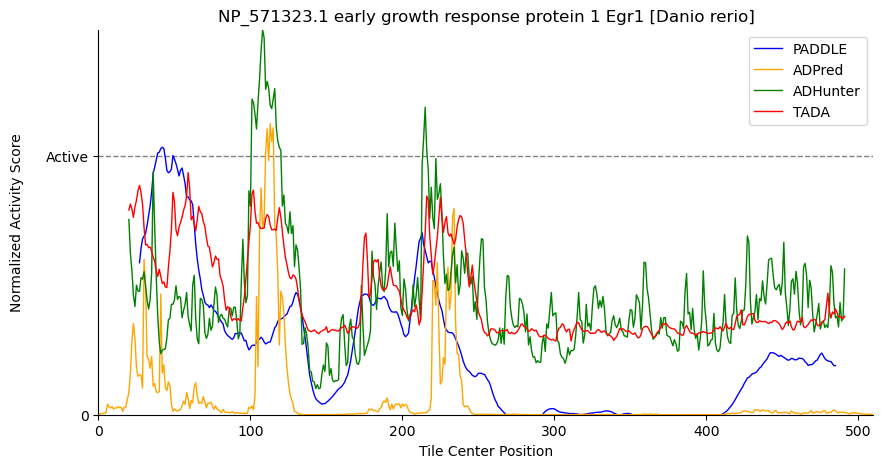

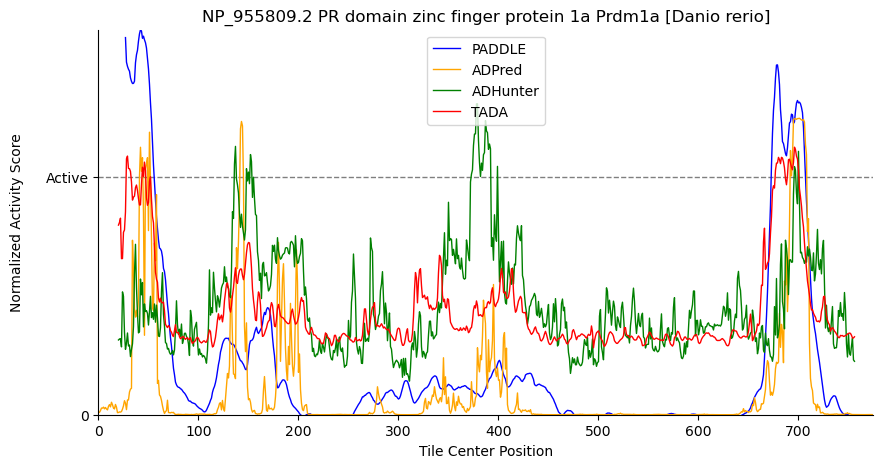

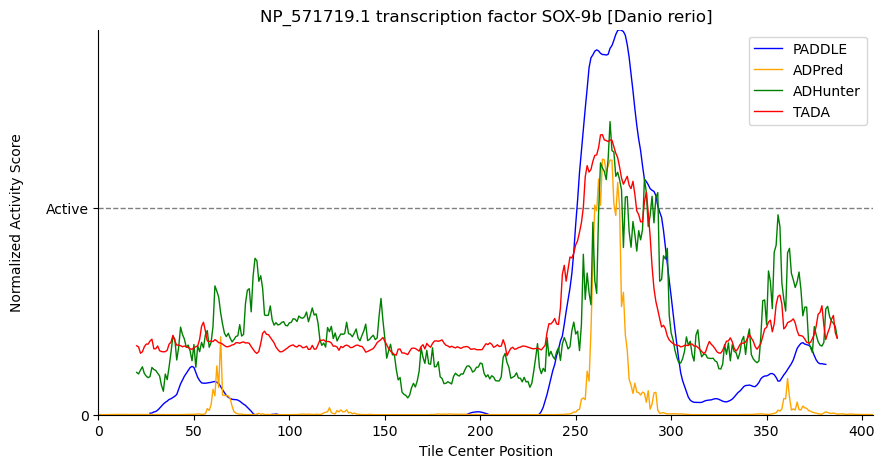

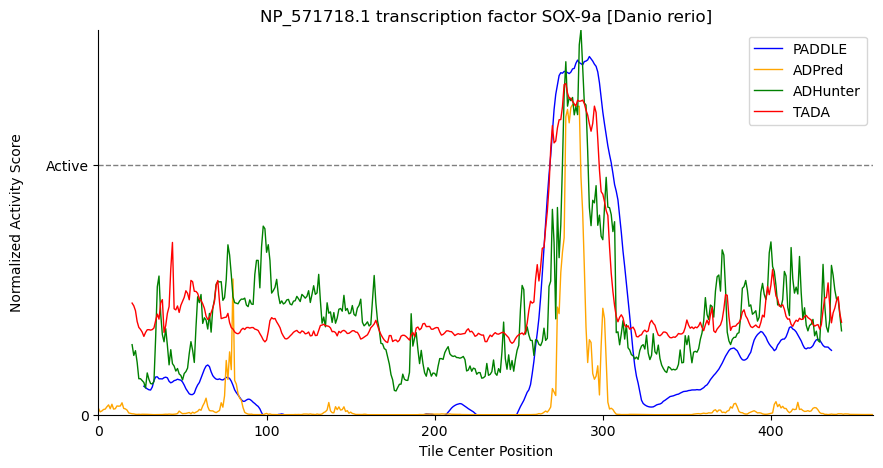

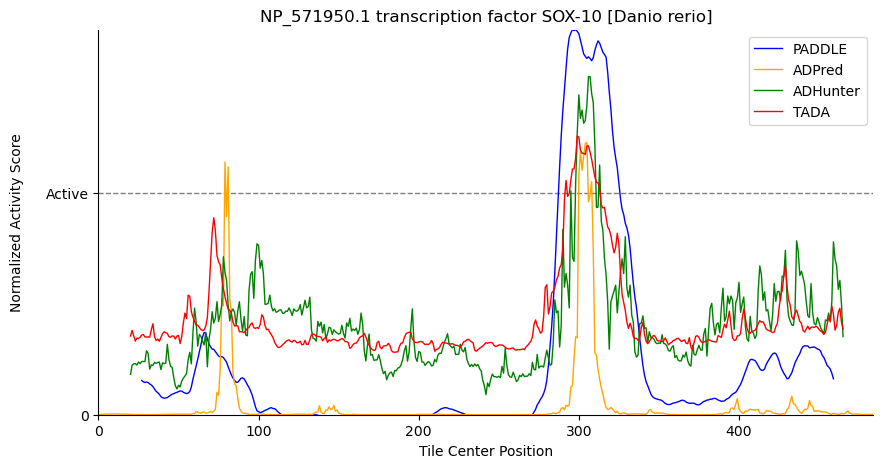

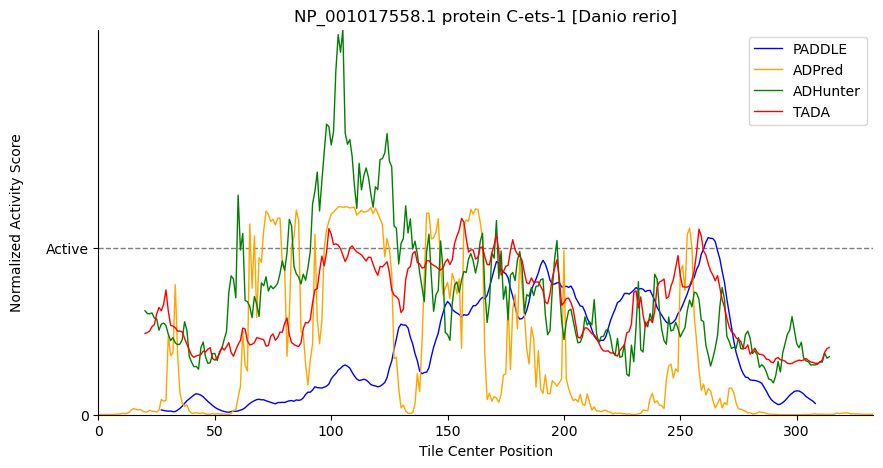

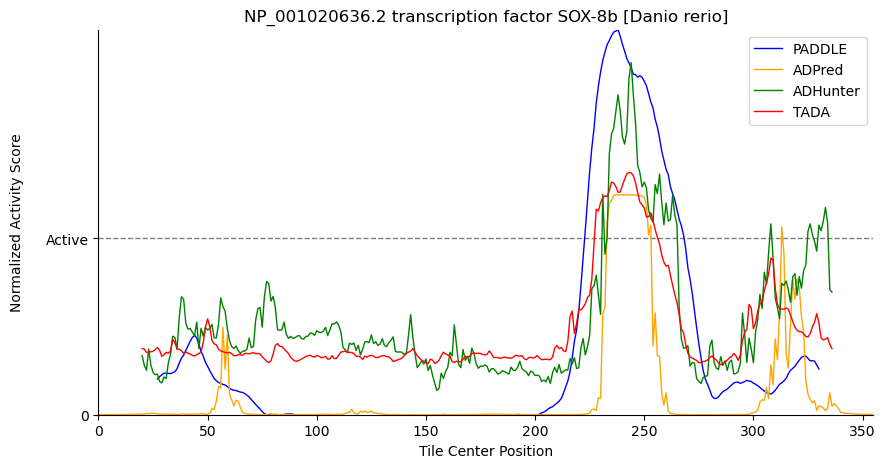

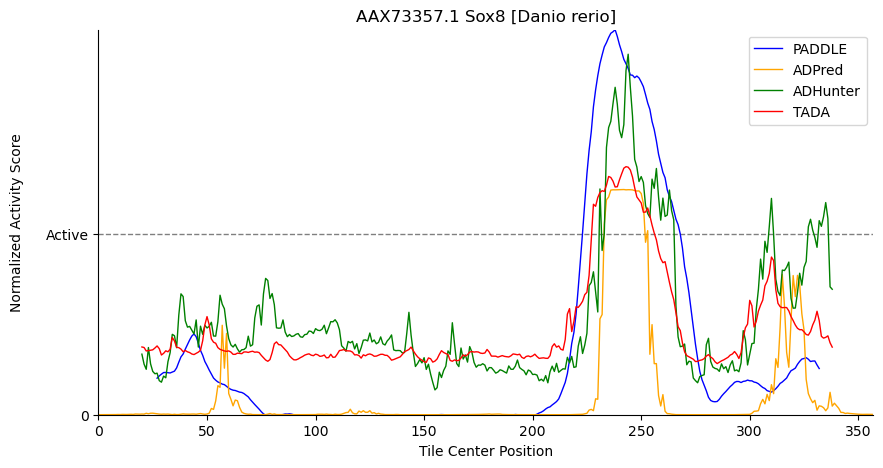

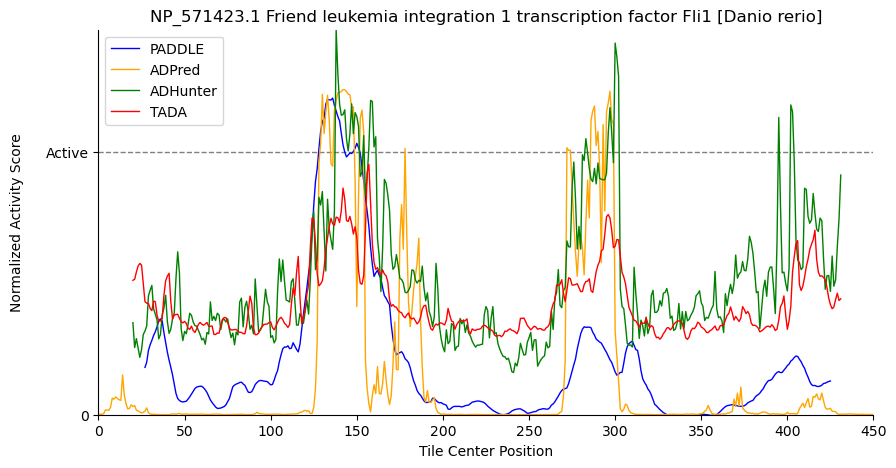

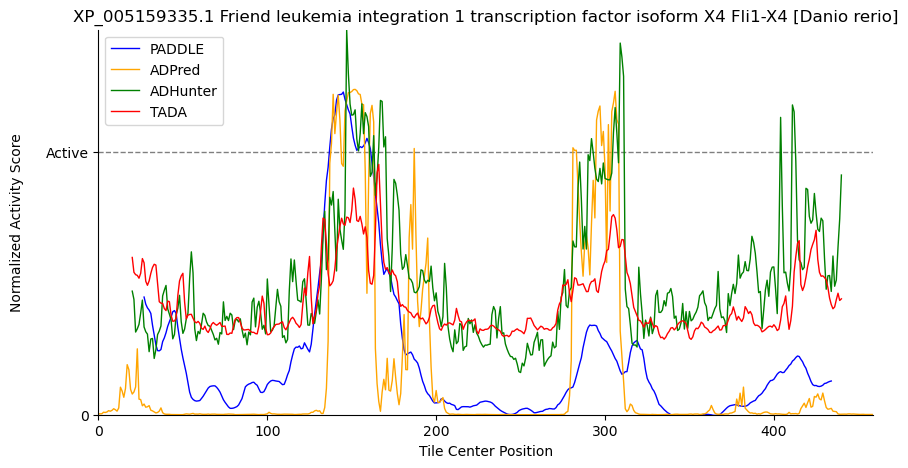

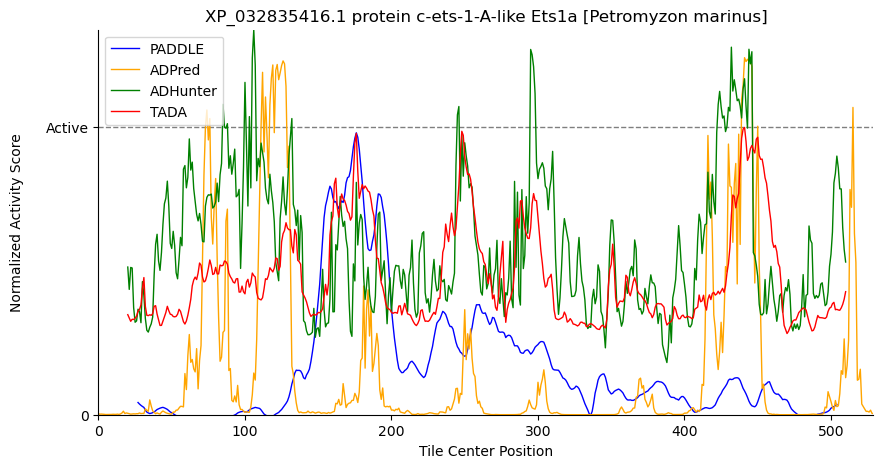

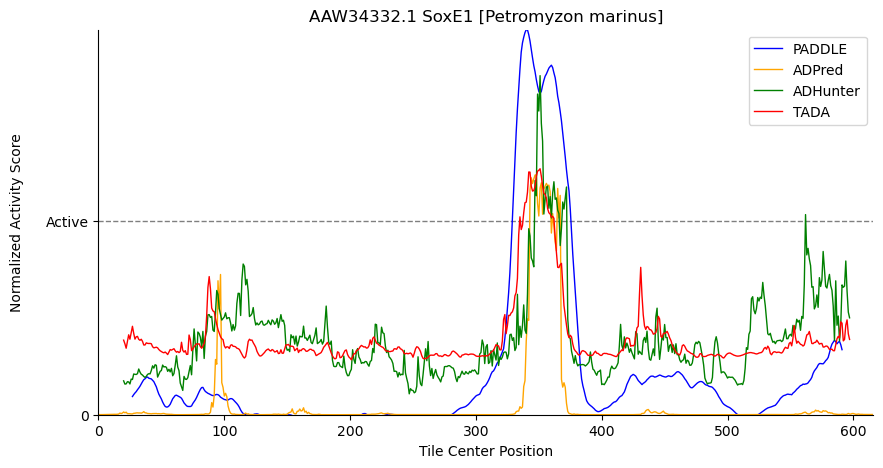

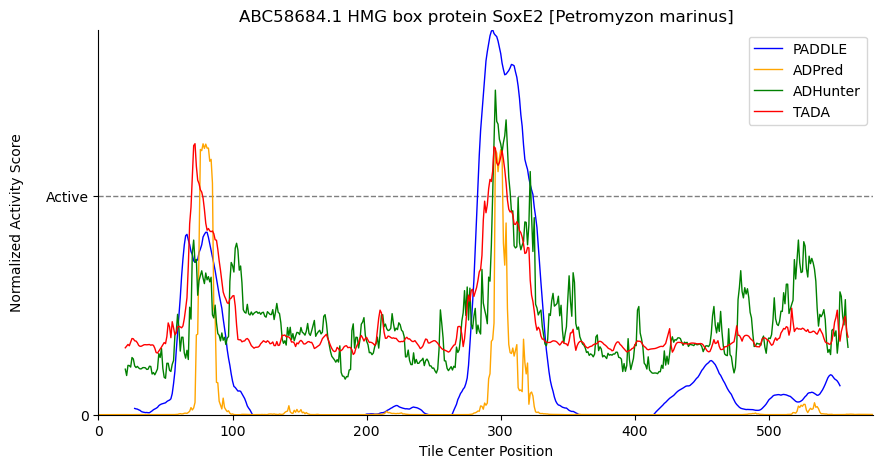

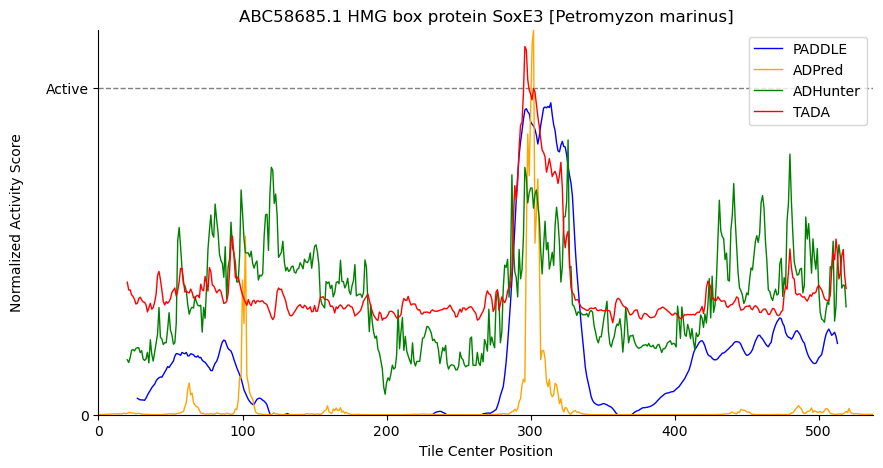

In [ ]:
pdf = PdfPages("../output/megan_TF_traces.pdf")

def norm_preds(preds, threshold):
    return (np.array(preds) - threshold)
    
for i in megan_TF_preds.index:
    sequence = megan_TF_preds["sequence"].iloc[i]
    paddle_centers, paddle_preds = megan_TF_preds["paddle_centers"].iloc[i], megan_TF_preds["paddle_preds"].iloc[i]
    adpred_preds = megan_TF_preds["adpred_preds"].iloc[i]
    adhunter_centers, adhunter_preds = megan_TF_preds["adhunter_centers"].iloc[i], megan_TF_preds["adhunter_preds"].iloc[i]
    tada_centers, tada_preds = megan_TF_preds["tada_centers"].iloc[i], megan_TF_preds["tada_preds"].iloc[i]

    fig, ax = plt.subplots(figsize=(10,5))

        # Normalizing all to 0.8
    # ax.plot([0, len(sequence)-1], [.8, .8], '-', c='orange')
    # ax.plot([0, len(sequence)-1], [4/5, 4/5], '-', c='b')
    # ax.plot([0, len(sequence)-1], [100000/125000, 100000/125000], '-', c='green')
    # ax.plot([0, len(sequence)-1], [.5 / 0.625, .5 / 0.625], '-', c='red')
    ax.plot([0, len(sequence)-1], [.8, .8], '--', c='black', alpha = 0.5, lw = 1)



    # Plot activity traces for all three predictors and their activity thresholds
    ax.plot(paddle_centers, np.array(paddle_preds) / 5, c='b', label='PADDLE', lw = 1)
    ax.plot(np.arange(len(sequence)), adpred_preds, c='orange', label='ADPred', lw = 1)
    ax.plot(adhunter_centers, np.array(adhunter_preds) / 125000, c='green', label='ADHunter', lw = 1)
    ax.plot(tada_centers, np.array(tada_preds) / 0.625, c='red', label='TADA', lw = 1)

    max_val = max(
        np.max(np.array(paddle_preds) / 5),
        np.max(adpred_preds),
        np.max(np.array(adhunter_preds) / 125000),
        np.max(np.array(tada_preds) / 0.625)
    )


    ax.set_title(megan_TF_preds["id"].iloc[i])
    ax.legend()
    ax.set_ylim(0, max_val)
    ax.margins(x=0)

    ax.set_xlabel('Tile Center Position')
    ax.set_ylabel('Normalized Activity Score\n')

    ax.set_yticks([0, 0.8])         # Only show the x-axis tick at 0
    ax.set_yticklabels([0, 'Active'])
    
    # Plot protein sequence on a secondary x-axis
    # Comment out this block of code if it looks too messy for you
    # ax2 = ax.twiny()
    # ax2.set_xticks(np.arange(len(sequence)))
    # ax2.set_xticklabels([aa for aa in sequence], fontsize=3)

    sns.despine()

    pdf.savefig()
    plt.show()
    
pdf.close()

In [11]:
my_predictor = py_predictor.Predictor("../../AD_predictor_project/Paper_AD_predictor/AD_predictor/output/parrot_lambert_tf_aggreg_preds_output", 
                                                dtype="residues")

In [21]:
len(megan_TF_preds)

14

Text(0.5, 0.95, 'Megan Fish TFs: Consensus Predictions')

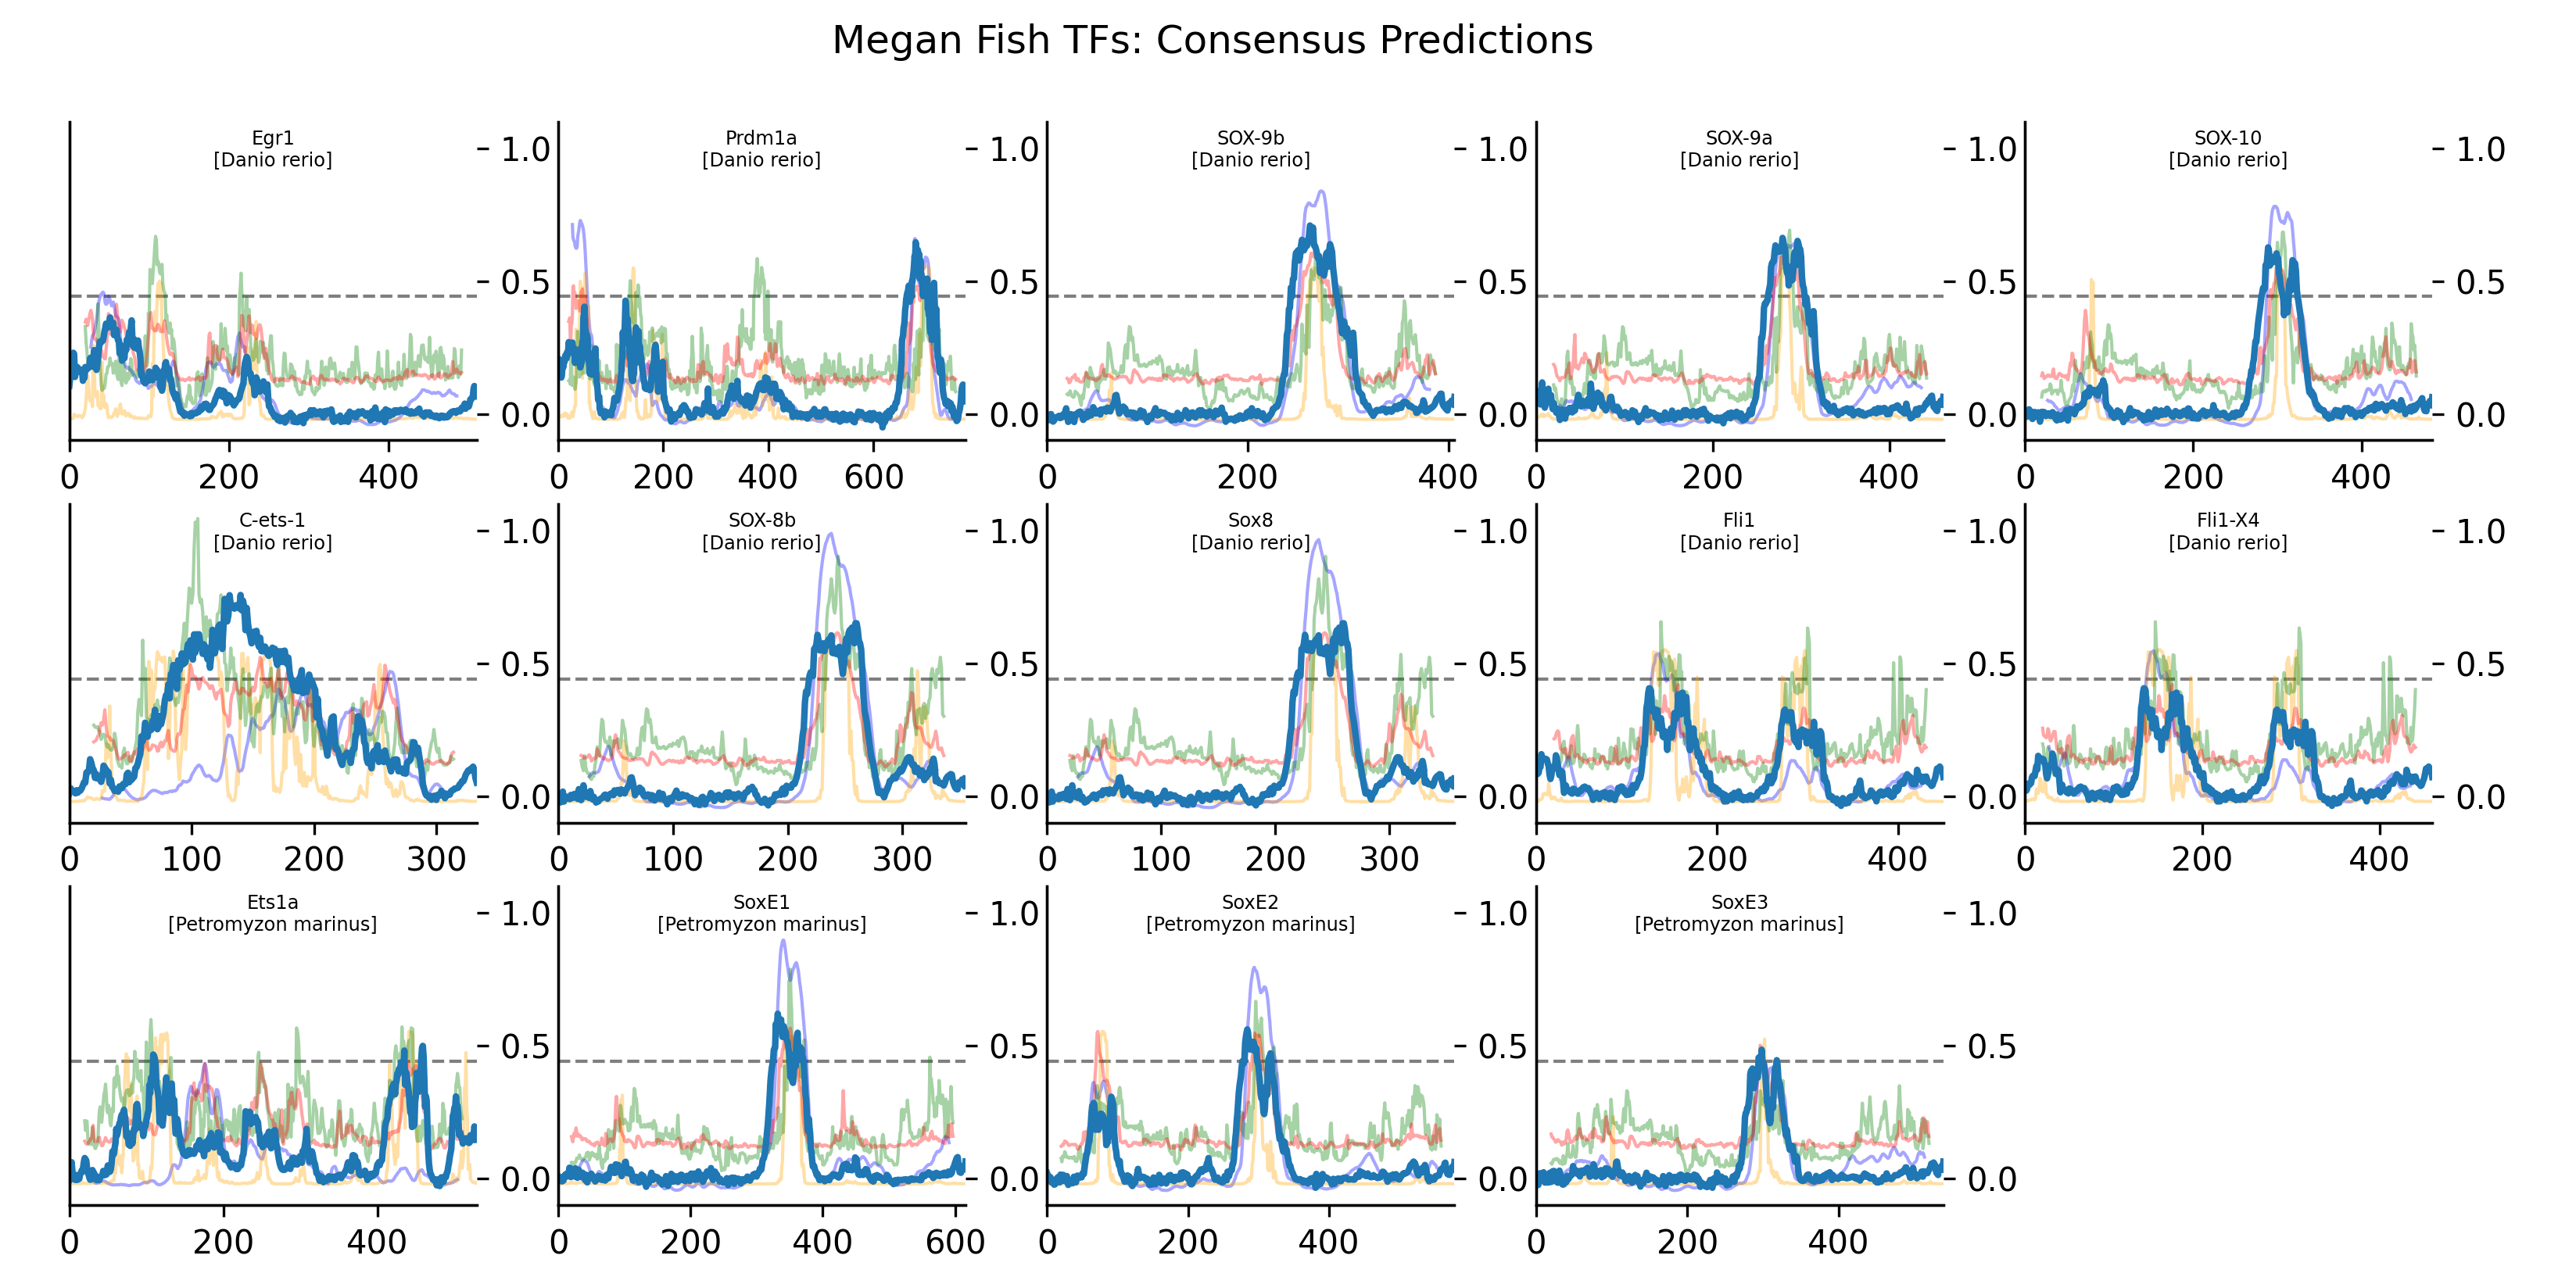

In [60]:

def norm_preds(preds, threshold):
    return (np.array(preds) - threshold)


fig, axs = plt.subplots(3, 5, figsize = (13, 6), sharey = True, dpi = 300)
axs = axs.flatten()

for i in megan_TF_preds.index:
    ax = axs[i]

    sequence = megan_TF_preds["sequence"].iloc[i]
    paddle_centers, paddle_preds = megan_TF_preds["paddle_centers"].iloc[i], megan_TF_preds["paddle_preds"].iloc[i]
    adpred_preds = megan_TF_preds["adpred_preds"].iloc[i]
    adhunter_centers, adhunter_preds = megan_TF_preds["adhunter_centers"].iloc[i], megan_TF_preds["adhunter_preds"].iloc[i]
    tada_centers, tada_preds = megan_TF_preds["tada_centers"].iloc[i], megan_TF_preds["tada_preds"].iloc[i]

    
    ax.plot([0, len(sequence)-1], [.8, .8], '--', c='black', alpha = 0.5, lw = 1)

    # Plot activity traces for all three predictors and their activity thresholds
    ax.plot(paddle_centers, np.array(paddle_preds) / 5, c='b', label='PADDLE', lw = 1, alpha = 0.35)
    ax.plot(np.arange(len(sequence)), adpred_preds, c='orange', label='ADPred', lw = 1, alpha = 0.35)
    ax.plot(adhunter_centers, np.array(adhunter_preds) / 125000, c='green', label='ADHunter', lw = 1, alpha = 0.35)
    ax.plot(tada_centers, np.array(tada_preds) / 0.625, c='red', label='TADA', lw = 1, alpha = 0.35)

    ax2 = ax.twinx()
    ax2.plot(my_predictor.predict(sequence), label = "Consensus", lw = 2)
    ax2.set_ylim(-0.1, 1.1)

    max_val = max(
        np.max(np.array(paddle_preds) / 5),
        np.max(adpred_preds),
        np.max(np.array(adhunter_preds) / 125000),
        np.max(np.array(tada_preds) / 0.625)
    )


    ax.set_title(megan_TF_preds["id"].iloc[i].split(" ")[-3]+"\n"+" ".join(megan_TF_preds["id"].iloc[i].split(" ")[-2:]), fontsize = "xx-small", y = 0.8)
    #ax.legend()
    #ax.set_ylim(0, max_val)
    ax.margins(x=0)

    ax.set_xlabel('')
    ax.set_ylabel(' ')
    ax2.set_ylabel(" ")

    ax.set_yticks([])         # Only show the x-axis tick at 0
    #ax.set_yticklabels([0, 'Active'], rotation = 0)
    

    sns.despine()

    #plt.show()

axs[-1].set_visible(False)
#plt.tight_layout(pad = 0)

plt.suptitle("Megan Fish TFs: Consensus Predictions", y = 0.95)